In [2]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import signal
import heyoka as hy
from celmech import Poincare, PoincareHamiltonian
from celmech.disturbing_function import laplace_b, df_coefficient_Ctilde, evaluate_df_coefficient_dict
import symengine as se
import time
import sympy as sp
from sympy import init_printing

In [3]:
#constants and helper functions
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

#from celmech docs
def get_pomega(kap,eta):
    return np.arctan2(-eta,kap)

def get_ecc(kap,eta,L):
    P = (kap**2 + eta**2)/2
    return np.sqrt(1 - (1 - P/L)**2)

In [4]:

def hk_integrate(pham,sim_time,num_data_points):
    #H_num = pham.H.subs(dict(pham.H_params))
    H_se = se.sympify(pham.H)
    clean_params_se = {se.sympify(k): v for k, v in dict(pham.H_params).items()
                   if not (hasattr(v, '__float__') and np.isnan(float(v)))}
    H_num = H_se.subs(clean_params_se)
    nan_symbols = {s: 0 for s in H_num.free_symbols 
               if str(s) not in {'Lambda1', 'Lambda2', 'eta1', 'eta2', 
                                  'kappa1', 'kappa2', 'lambda1', 'lambda2',
                                  'rho1', 'rho2', 'sigma1', 'sigma2'}}
    H_num = H_num.subs(nan_symbols)

    
    rho1,rho2,sigma1,sigma2 = se.symbols('rho1 rho2 sigma1 sigma2')
    sym_map = {s: 0 for s in H_num.free_symbols if str(s) in ('rho1', 'rho2', 'sigma1', 'sigma2')}
    H_planar = H_num.subs(sym_map)
    #H_planar = H_num.subs({rho1: 0, rho2: 0, sigma1: 0, sigma2: 0})
    H_planar = se.sympify(H_planar)
    print(sorted(str(s) for s in H_planar.free_symbols))

    lam1,lam2 = se.symbols('lambda1 lambda2')
    Lam1,Lam2 = se.symbols('Lambda1 Lambda2')
    eta1,eta2 = se.symbols('eta1 eta2')
    kap1, kap2 = se.symbols('kappa1 kappa2')

    print('*** Differentiating  ***')

    sym_dict = {str(s): s for s in H_planar.free_symbols}
    lam1 = sym_dict['lambda1']
    lam2 = sym_dict['lambda2']
    Lam1 = sym_dict['Lambda1']
    Lam2 = sym_dict['Lambda2']
    eta1 = sym_dict['eta1']
    eta2 = sym_dict['eta2']
    kap1 = sym_dict['kappa1']
    kap2 = sym_dict['kappa2']

    dLam1_dt = -se.diff(H_planar, lam1)
    dLam2_dt = -se.diff(H_planar, lam2)
    dlam1_dt =  se.diff(H_planar, Lam1)
    dlam2_dt =  se.diff(H_planar, Lam2)

    deta1_dt  = se.diff(H_planar, kap1)
    dkap1_dt  =  -se.diff(H_planar, eta1)
    deta2_dt  = se.diff(H_planar, kap2)
    dkap2_dt  =  -se.diff(H_planar, eta2)

    derivs = [dlam1_dt, dLam1_dt, dlam2_dt, dLam2_dt, deta1_dt, dkap1_dt, deta2_dt, dkap2_dt]

    vars_list = [lam1, Lam1, lam2, Lam2, eta1, kap1, eta2, kap2]
    func = se.Lambdify(vars_list,H_planar)

    jup = pham.state.particles[1]
    sat = pham.state.particles[2]

    initial_conditions = [jup.l, jup.Lambda, sat.l, sat.Lambda,jup.eta, jup.kappa, sat.eta, sat.kappa]
    derivs_at_0 = func(*initial_conditions)

    lam1_hy, Lam1_hy, lam2_hy, Lam2_hy, eta1_hy, kap1_hy, eta2_hy, kap2_hy = hy.make_vars('lam1_hy', 'Lam1_hy', 'lam2_hy', 'Lam2_hy', 'eta1_hy', 'kap1_hy', 'eta2_hy', 'kap2_hy')

    eqs_hy = [hy.from_sympy(sp.sympify(eq), {sp.Symbol('lambda1'): lam1_hy, 
                                          sp.Symbol('Lambda1'): Lam1_hy,
                                          sp.Symbol('lambda2'): lam2_hy, 
                                          sp.Symbol('Lambda2'): Lam2_hy,
                                          sp.Symbol('eta1'): eta1_hy, 
                                          sp.Symbol('kappa1'): kap1_hy,
                                          sp.Symbol('eta2'): eta2_hy, 
                                          sp.Symbol('kappa2'): kap2_hy})
           for eq in derivs]

    ta = hy.taylor_adaptive(sys=[(lam1_hy, eqs_hy[0]),(Lam1_hy, eqs_hy[1]),(lam2_hy, eqs_hy[2]),(Lam2_hy, eqs_hy[3]),(eta1_hy,  eqs_hy[4]),(kap1_hy,  eqs_hy[5]),(eta2_hy,  eqs_hy[6]),(kap2_hy,  eqs_hy[7])],
    state=initial_conditions,
    high_accuracy= True,
    time=0.0,
    tol=1e-16)

    e_i = float(func(*ta.state))
    print(e_i)

    times = np.linspace(0,sim_time,int(num_data_points))*2*np.pi 
    e_sat = np.zeros(len(times))
    pomega_sat = np.zeros(len(times))
    e_j = np.zeros(len(times))
    pomega_j = np.zeros(len(times)) 
    a_sat = np.zeros(len(times))

    def get_sma(Lambda, m, M=1.0):
        return (Lambda / m) ** 2



    start = time.perf_counter()
    print('*** Starting Simulation ***')
    '''res, min_dt, max_dt, num_steps, callback, flat_states = ta.propagate_grid(times.tolist(), max_delta_t=0.01)

    flat_states = np.array(flat_states)

    num_vars = 8 
    state_matrix = flat_states.reshape(-1, num_vars)

    L_all   = state_matrix[:, 3]
    eta_all = state_matrix[:, 6]
    kap_all = state_matrix[:, 7]

    e_sat = get_ecc(kap_all, eta_all, L_all)
    pomega_sat = get_pomega(kap_all, eta_all)'''
    
    for i in tqdm(range(len(times))):
        ta.propagate_until(times[i],max_delta_t=float(10))
        L, eta, kap = ta.state[3], ta.state[6], ta.state[7]
        Lj, etaj, kapj = ta.state[1], ta.state[4], ta.state[5]
        e_sat[i] = get_ecc(kap, eta, L)
        pomega_sat[i] = get_pomega(kap, eta)
        e_j[i] = get_ecc(kapj, etaj, Lj)
        pomega_j = get_pomega(kapj, etaj)
        sat_particle = pham.state.particles[2]
        a_sat[i] = (L / sat_particle.m) ** 2

        
    end = time.perf_counter()

    e_f = float(func(*ta.state))
    print(e_f)
    e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
    print(f'Energy Percent Change: {e_per} %')
    
    print('*** Simulation Complete ***')

    print('Time elapsed  = ' + str(end-start) + ' seconds')

    return times, pomega_sat, e_sat, a_sat

## Massless Case 1st Order Sanity Checks

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166636097671e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:05<00:00, 19077.01it/s]


-8.880166636097618e-05
Energy Percent Change: 5.952011721696142e-13 %
*** Simulation Complete ***
Time elapsed  = 5.246022713000002 seconds


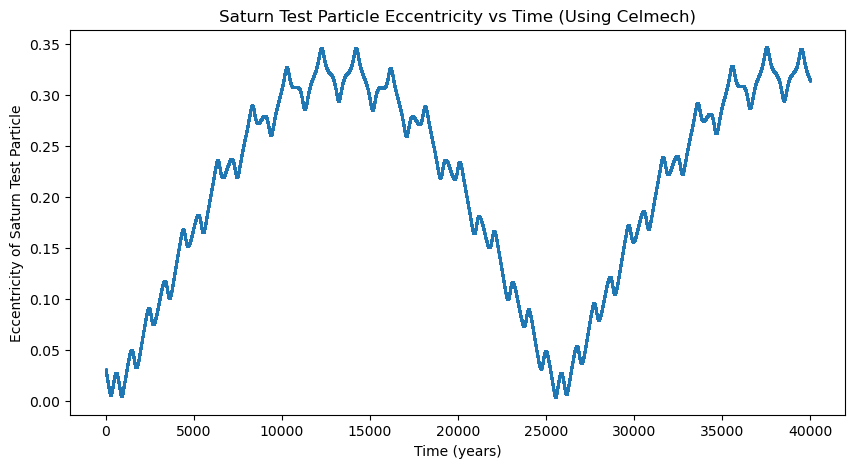

In [22]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.85

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1) 

pvars = Poincare.from_Simulation(sim)

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 4e4, 1e5)

plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), e_sat,s=1)
plt.ylabel('Eccentricity of Saturn Test Particle')
plt.xlabel("Time (years)")
plt.title('Saturn Test Particle Eccentricity vs Time (Using Celmech)')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166636097671e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:05<00:00, 18379.23it/s]


-8.880166636097618e-05
Energy Percent Change: 5.952011721696142e-13 %
*** Simulation Complete ***
Time elapsed  = 5.445549545999938 seconds


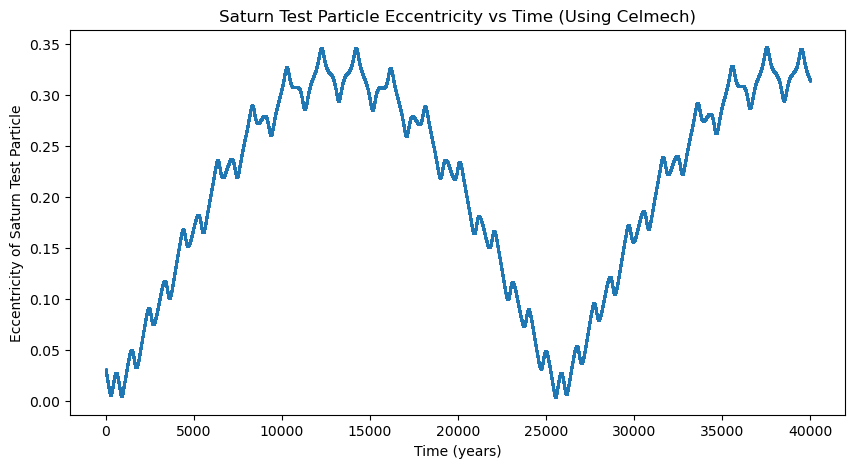

In [24]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.85

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_cosine_term([2,-1,0,-1,0,0],max_order=1,indexIn=1,indexOut=2)
pham.add_cosine_term([2,-1,-1,0,0,0],max_order=1,indexIn=1,indexOut=2)


times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 4e4, 1e5)

plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), e_sat,s=1)
plt.ylabel('Eccentricity of Saturn Test Particle')
plt.xlabel("Time (years)")
plt.title('Saturn Test Particle Eccentricity vs Time (Using Celmech)')
plt.show()

## Massless Case 2:1 2nd Order Sanity Check

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.88016663610541e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:07<00:00, 12569.95it/s]


-8.880166636105397e-05
Energy Percent Change: 1.3735411665440668e-13 %
*** Simulation Complete ***
Time elapsed  = 6.389740200998858 seconds


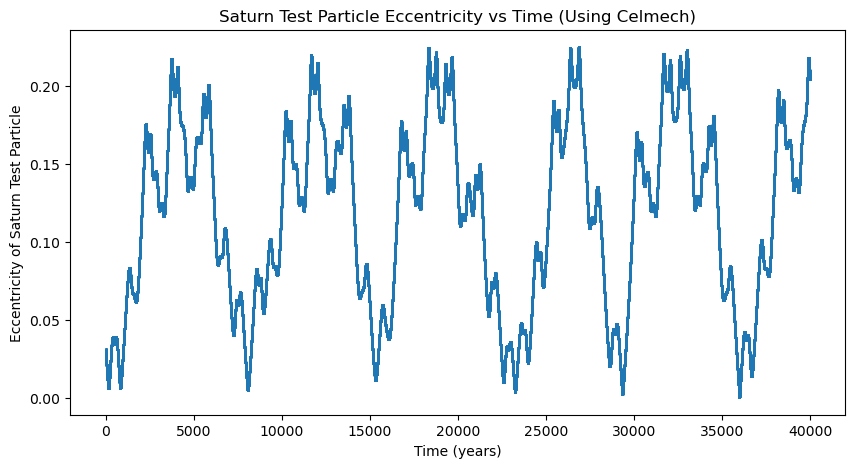

In [6]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.85

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
#pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2) 

pvars = Poincare.from_Simulation(sim)

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 4e4, 1e5)

plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), e_sat,s=1)
plt.ylabel('Eccentricity of Saturn Test Particle')
plt.xlabel("Time (years)")
plt.title('Saturn Test Particle Eccentricity vs Time (Using Celmech)')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166636105411e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:05<00:00, 16729.55it/s]


-8.880166636105397e-05
Energy Percent Change: 1.5261568517156293e-13 %
*** Simulation Complete ***
Time elapsed  = 5.985442918999979 seconds


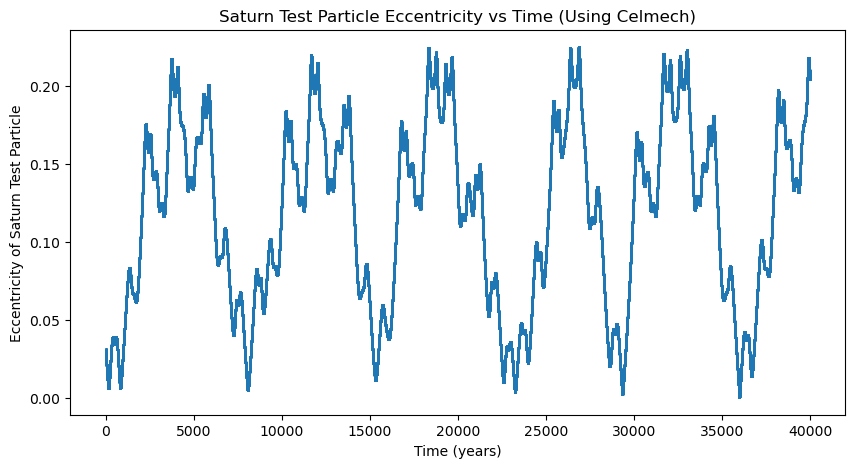

In [8]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.85

pvars = Poincare.from_Simulation(sim)

times = np.linspace(0,4e4,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
a_sat = np.zeros(len(times))

pham = PoincareHamiltonian(pvars)
#pham.add_secular_terms(indexIn=1, indexOut=2)
pham.add_cosine_term([4,-2,0,-2,0,0],max_order=2,indexIn=1,indexOut=2)
pham.add_cosine_term([2,-1,0,-1,0,0],max_order=2,indexIn=1,indexOut=2)
pham.add_cosine_term([4,-2,-2,0,0,0],max_order=2,indexIn=1,indexOut=2)
pham.add_cosine_term([2,-1,-1,0,0,0],max_order=2,indexIn=1,indexOut=2)
pham.add_cosine_term([4,-2,-1,-1,0,0],max_order=2,indexIn=1,indexOut=2)

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 4e4, 1e5)

plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), e_sat,s=1)
plt.ylabel('Eccentricity of Saturn Test Particle')
plt.xlabel("Time (years)")
plt.title('Saturn Test Particle Eccentricity vs Time (Using Celmech)')
plt.show()

In [35]:
pham_check = PoincareHamiltonian(pvars)
pham_check.add_MMR_terms(p=2, q=1, indexIn=1, indexOut=2, max_order=2)
print(pham_check.df)

<IPython.core.display.Math object>

None


In [28]:
pham_check2 = PoincareHamiltonian(pvars)
pham_check2.add_cosine_term([4,-2,0,-2,0,0],max_order=2,indexIn=1,indexOut=2)
pham_check2.add_cosine_term([2,-1,0,-1,0,0],max_order=2,indexIn=1,indexOut=2)
pham_check2.add_cosine_term([4,-2,-2,0,0,0],max_order=2,indexIn=1,indexOut=2)
pham_check2.add_cosine_term([2,-1,-1,0,0,0],max_order=2,indexIn=1,indexOut=2)
pham_check2.df

<IPython.core.display.Math object>

## Isolating Chaos Term

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166636031379e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:06<00:00, 15684.75it/s]


-8.880166636031478e-05
Energy Percent Change: 1.1140945017616975e-12 %
*** Simulation Complete ***
Time elapsed  = 5.829580106999856 seconds


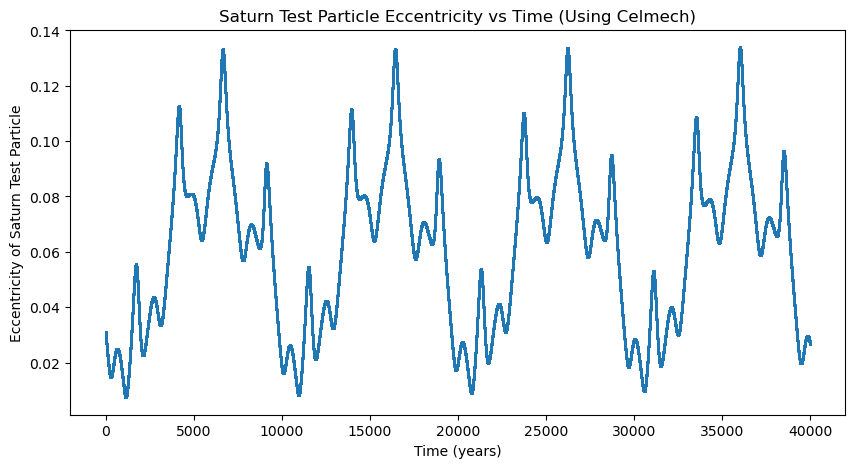

In [11]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.85

pvars = Poincare.from_Simulation(sim)

times = np.linspace(0,4e4,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
a_sat = np.zeros(len(times))

pham = PoincareHamiltonian(pvars)
#pham.add_secular_terms(indexIn=1, indexOut=2)
pham.add_cosine_term([4,-2,0,-2,0,0],max_order=2,indexIn=1,indexOut=2)
pham.add_cosine_term([4,-2,-2,0,0,0],max_order=2,indexIn=1,indexOut=2)
pham.add_cosine_term([4,-2,-1,-1,0,0],max_order=2,indexIn=1,indexOut=2)

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 4e4, 1e5)

plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), e_sat,s=1)
plt.ylabel('Eccentricity of Saturn Test Particle')
plt.xlabel("Time (years)")
plt.title('Saturn Test Particle Eccentricity vs Time (Using Celmech)')
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166636105411e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:05<00:00, 17291.08it/s]


-8.880166636105397e-05
Energy Percent Change: 1.5261568517156293e-13 %
*** Simulation Complete ***
Time elapsed  = 5.79074273399965 seconds


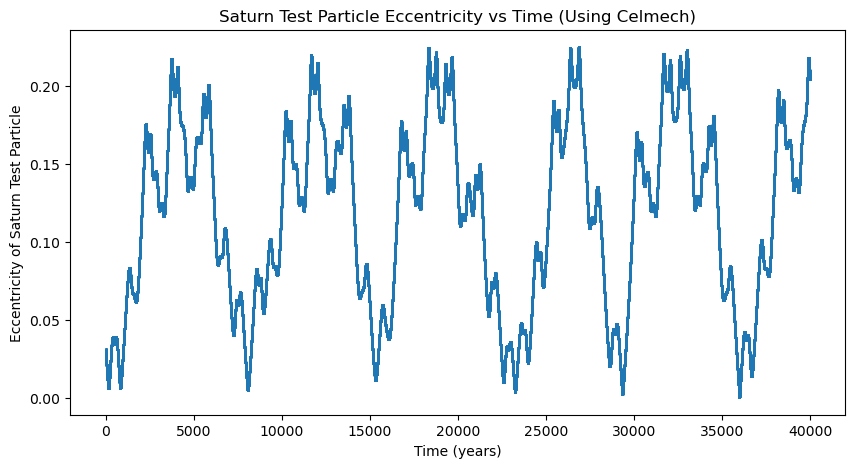

In [20]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.85

pvars = Poincare.from_Simulation(sim)

times = np.linspace(0,4e4,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
a_sat = np.zeros(len(times))

pham = PoincareHamiltonian(pvars)
#pham.add_secular_terms(indexIn=1, indexOut=2)
pham.add_cosine_term([4,-2,0,-2,0,0],max_order=2,indexIn=1,indexOut=2)
pham.add_cosine_term([2,-1,0,-1,0,0],max_order=2,indexIn=1,indexOut=2)
pham.add_cosine_term([4,-2,-2,0,0,0],max_order=2,indexIn=1,indexOut=2)
pham.add_cosine_term([2,-1,-1,0,0,0],max_order=2,indexIn=1,indexOut=2)
pham.add_cosine_term([4,-2,-1,-1,0,0],max_order=2,indexIn=1,indexOut=2)

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 4e4, 1e5)

plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), e_sat,s=1)
plt.ylabel('Eccentricity of Saturn Test Particle')
plt.xlabel("Time (years)")
plt.title('Saturn Test Particle Eccentricity vs Time (Using Celmech)')
plt.show()

Initial Energy: -8.880166636099383e-05
['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.88016663609939e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:11<00:00, 8669.40it/s]


-8.88016663609979e-05
Energy Percent Change: 4.50216271256416e-12 %
*** Simulation Complete ***
Time elapsed  = 11.540025549998973 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka')

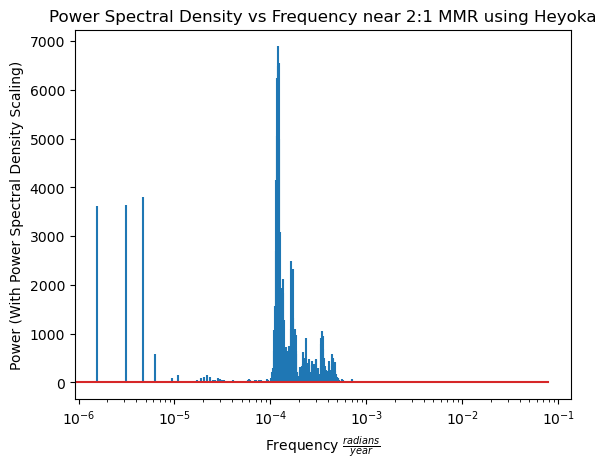

In [28]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(max_order=2, indexIn = 1, indexOut=2)
#pham.add_cosine_term([4,-2,0,-2,0,0],max_order=2,indexIn=1,indexOut=2)
pham.add_cosine_term([2,-1,0,-1,0,0],max_order=2,indexIn=1,indexOut=2)
#pham.add_cosine_term([4,-2,-2,0,0,0],max_order=2,indexIn=1,indexOut=2)
pham.add_cosine_term([2,-1,-1,0,0,0],max_order=2,indexIn=1,indexOut=2)
#pham.add_cosine_term([4,-2,-1,-1,0,0],max_order=2,indexIn=1,indexOut=2)

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
a_sat = np.zeros(len(times))

e_i = pham.calculate_energy()
print('Initial Energy: '+ str(e_i))

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 4e6, 1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka')

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.88016663609939e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:02<00:00, 40956.77it/s]


-8.880166636099207e-05
Energy Percent Change: 2.0603117498174967e-12 %
*** Simulation Complete ***
Time elapsed  = 2.4464865019981517 seconds


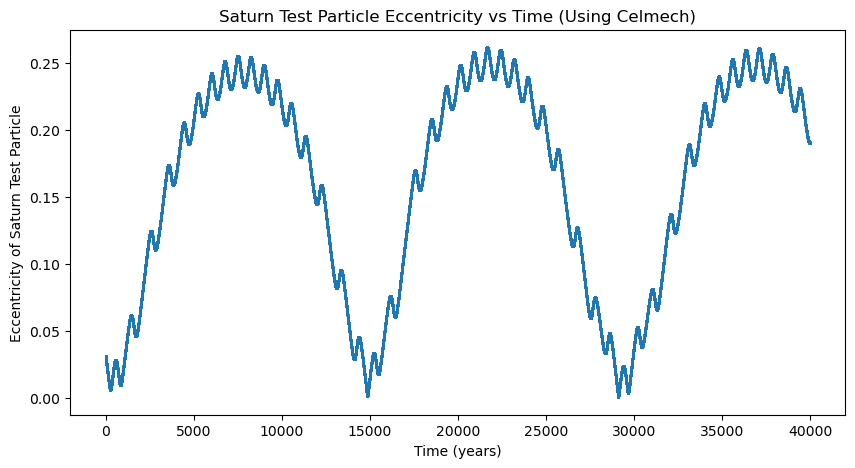

In [34]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.85

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(max_order=2, indexIn=1, indexOut=2)
pham.add_cosine_term([2,-1,0,-1,0,0],max_order=1,indexIn=1,indexOut=2)
pham.add_cosine_term([2,-1,-1,0,0,0],max_order=1,indexIn=1,indexOut=2)


times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 4e4, 1e5)

plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), e_sat,s=1)
plt.ylabel('Eccentricity of Saturn Test Particle')
plt.xlabel("Time (years)")
plt.title('Saturn Test Particle Eccentricity vs Time (Using Celmech)')
plt.show()

Initial Energy: -8.880166636099383e-05
['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.88016663609939e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 20139.74it/s]


-8.88016663609979e-05
Energy Percent Change: 4.50216271256416e-12 %
*** Simulation Complete ***
Time elapsed  = 4.967409889999544 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka')

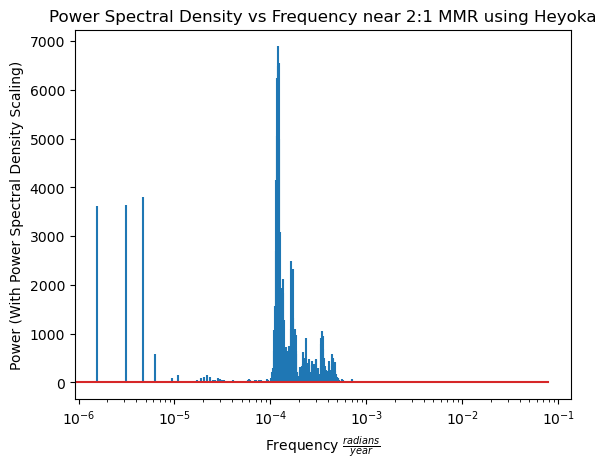

In [36]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(max_order=2, indexIn=1, indexOut=2)
pham.add_cosine_term([2,-1,0,-1,0,0],max_order=1,indexIn=1,indexOut=2)
pham.add_cosine_term([2,-1,-1,0,0,0],max_order=1,indexIn=1,indexOut=2)

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
a_sat = np.zeros(len(times))

e_i = pham.calculate_energy()
print('Initial Energy: '+ str(e_i))

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 4e6, 1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka')

Initial Energy: -8.880166636029665e-05
['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166636029671e-05
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 22731.12it/s]


-8.880166636030157e-05
Energy Percent Change: 5.463641529188553e-12 %
*** Simulation Complete ***
Time elapsed  = 4.401127682998776 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka')

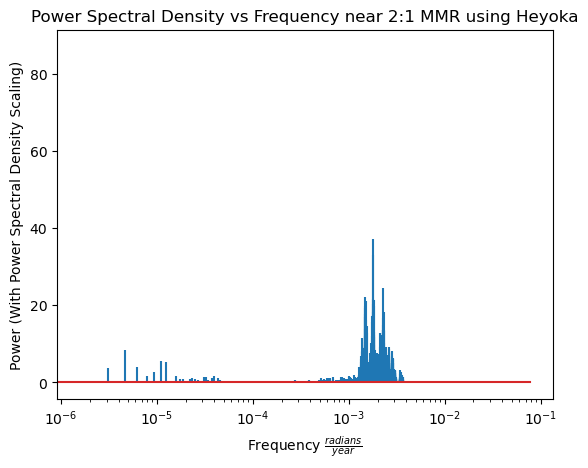

In [46]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(max_order=2, indexIn=1, indexOut=2)
pham.add_cosine_term([2,-1,0,-1,0,0],max_order=1,indexIn=1,indexOut=2)

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
a_sat = np.zeros(len(times))

e_i = pham.calculate_energy()
print('Initial Energy: '+ str(e_i))

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 4e6, 1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka')

In [49]:
pham_check = PoincareHamiltonian(pvars)
pham_check.add_secular_terms(max_order=2, indexIn = 1, indexOut =2)
pham_check.add_cosine_term([2,-1,0,-1,0,0],max_order=1,indexIn=1,indexOut=2)
pham_check.df

<IPython.core.display.Math object>

## Massive Case

100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [01:22<00:00, 1208.02it/s]


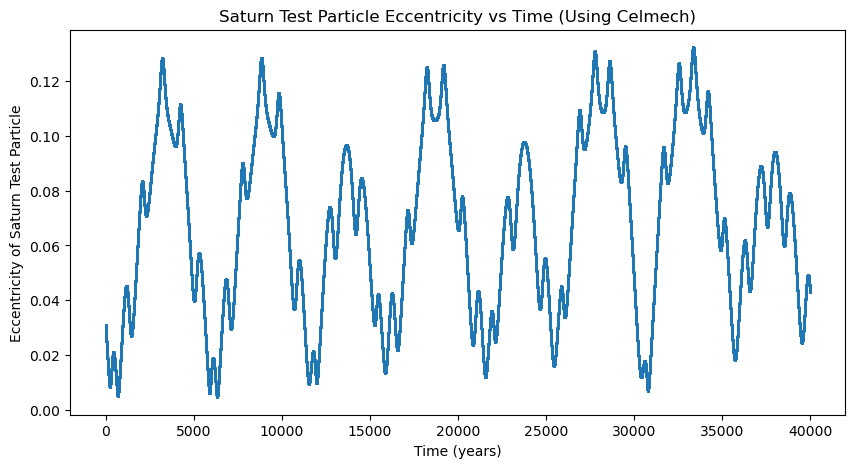

In [33]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.85

pvars = Poincare.from_Simulation(sim)

times = np.linspace(0,4e4,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
a_sat = np.zeros(len(times))

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn = 1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1, indexIn = 1, indexOut=2, max_order=1)
pvars = Poincare.from_Simulation(sim)

for i in tqdm(range(len(times))):
    pham.integrate(times[i])
    a_sat[i] = pham.state.particles[2].a
    e_sat[i] = pham.state.particles[2].e
    long_peri_sat[i] = pham.state.particles[2].pomega

plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), e_sat,s=1)
plt.ylabel('Eccentricity of Saturn Test Particle')
plt.xlabel("Time (years)")
plt.title('Saturn Test Particle Eccentricity vs Time (Using Celmech)')
plt.show()

100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [01:24<00:00, 1189.37it/s]


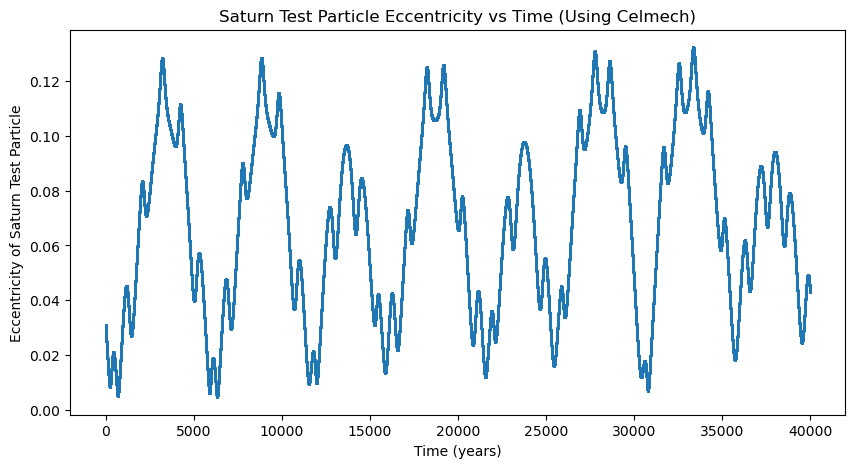

In [31]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.85

pvars = Poincare.from_Simulation(sim)

times = np.linspace(0,4e4,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
a_sat = np.zeros(len(times))

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(max_order=2, indexIn = 1, indexOut=2)
pham.add_cosine_term([2,-1,-1,0,0,0],indexIn=1,indexOut=2)
pham.add_cosine_term([2,-1,0,-1,0,0],indexIn=1,indexOut=2)

for i in tqdm(range(len(times))):
    pham.integrate(times[i])
    a_sat[i] = pham.state.particles[2].a
    e_sat[i] = pham.state.particles[2].e
    long_peri_sat[i] = pham.state.particles[2].pomega

plt.figure(figsize=(10, 5))
plt.scatter(times/(2*np.pi), e_sat,s=1)
plt.ylabel('Eccentricity of Saturn Test Particle')
plt.xlabel("Time (years)")
plt.title('Saturn Test Particle Eccentricity vs Time (Using Celmech)')
plt.show()

In [42]:
pham_check = PoincareHamiltonian(pvars)
pham_check.add_secular_terms(max_order=2, indexIn=1, indexOut=2)
pham_check.add_MMR_terms(p=2, q=1, indexIn=1, indexOut=2, max_order=1)
init_printing()
pham_check.df

<IPython.core.display.Math object>

In [43]:
pham_check2 = PoincareHamiltonian(pvars)
pham_check2.add_secular_terms(max_order=2, indexIn=1, indexOut=2)
pham_check2.add_cosine_term([2,-1,-1,0,0,0],indexIn=1,indexOut=2)
pham_check2.add_cosine_term([2,-1,0,-1,0,0],indexIn=1,indexOut=2)
pham_check2.df

<IPython.core.display.Math object>

Initial Energy: -0.00010494203027936993
['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-0.00010494203027936991
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:10<00:00, 9595.26it/s]


-0.00010494203027964175
Energy Percent Change: 2.590350014886907e-10 %
*** Simulation Complete ***
Time elapsed  = 10.425775990002876 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka')

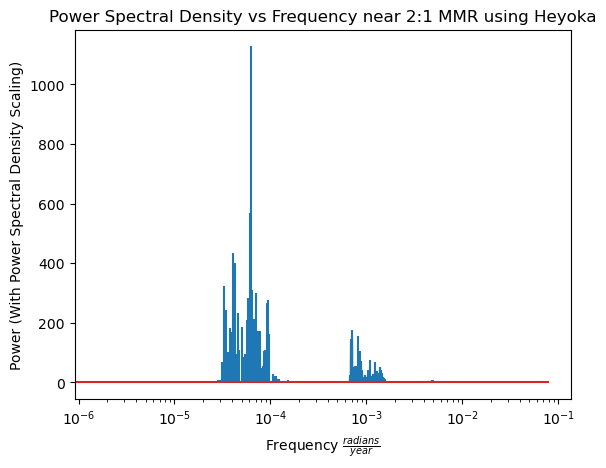

In [30]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(max_order=2, indexIn = 1, indexOut=2)
pham.add_cosine_term([2,-1,-1,0,0,0],indexIn=1,indexOut=2)
pham.add_cosine_term([2,-1,0,-1,0,0],indexIn=1,indexOut=2)

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
a_sat = np.zeros(len(times))

e_i = pham.calculate_energy()
print('Initial Energy: '+ str(e_i))

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 4e6, 1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka (with secular terms)')

Initial Energy: -0.00010494198126201337
['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-0.00010494198126201336
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 20395.77it/s]


-0.00010494198126186103
Energy Percent Change: 1.4515678416046218e-10 %
*** Simulation Complete ***
Time elapsed  = 4.905435380002018 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka (without secular terms)')

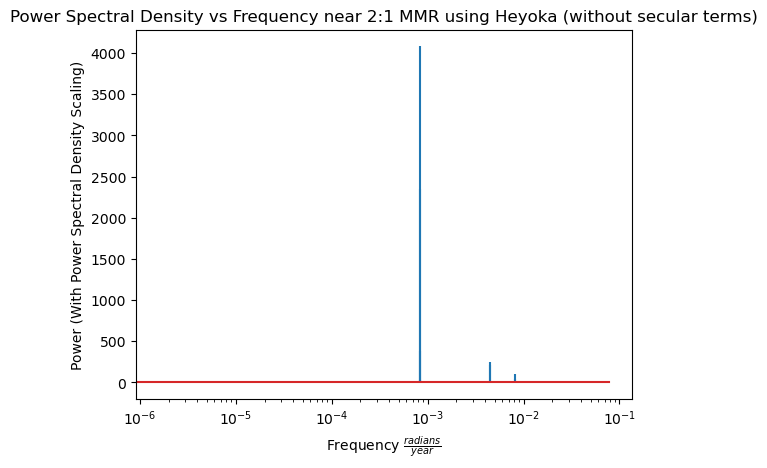

In [39]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_cosine_term([2,-1,-1,0,0,0],indexIn=1,indexOut=2)
pham.add_cosine_term([2,-1,0,-1,0,0],indexIn=1,indexOut=2)

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
a_sat = np.zeros(len(times))

e_i = pham.calculate_energy()
print('Initial Energy: '+ str(e_i))

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 4e6, 1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka (without secular terms)')

Initial Energy: -0.00010494003738509172
['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-0.00010494003738509171
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 22973.10it/s]


-0.00010494003738514632
Energy Percent Change: 5.204561176068001e-11 %
*** Simulation Complete ***
Time elapsed  = 4.364669741000057 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka (with secular terms)')

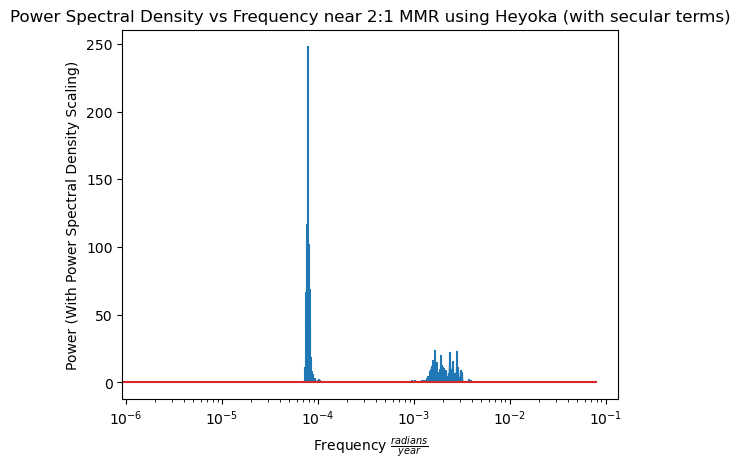

In [5]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(max_order=2, indexIn = 1, indexOut=2)
pham.add_cosine_term([2,-1,0,-1,0,0],indexIn=1,indexOut=2)

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
a_sat = np.zeros(len(times))

e_i = pham.calculate_energy()
print('Initial Energy: '+ str(e_i))

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 4e6, 1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka (with secular terms)')

In [54]:
pham_check = PoincareHamiltonian(pvars)
pham_check.add_secular_terms(max_order=2, indexIn = 1, indexOut = 2)
pham_check.add_cosine_term([2,-1,0,-1,0,0], indexIn = 1, indexOut = 2)
pham_check.df

<IPython.core.display.Math object>

In [6]:
pham_check_secular = PoincareHamiltonian(pvars)
pham_check_secular.add_secular_terms(max_order=2, indexIn = 1, indexOut = 2)
pham_check_secular.df

<IPython.core.display.Math object>

Initial Energy: -0.00010494190729828045
['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-0.00010494190729828045
*** Starting Simulation ***


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [00:04<00:00, 22040.54it/s]


-0.00010494190729831059
Energy Percent Change: 2.8721433763755216e-11 %
*** Simulation Complete ***
Time elapsed  = 4.539508254998509 seconds


Text(0.5, 1.0, 'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka (with secular terms)')

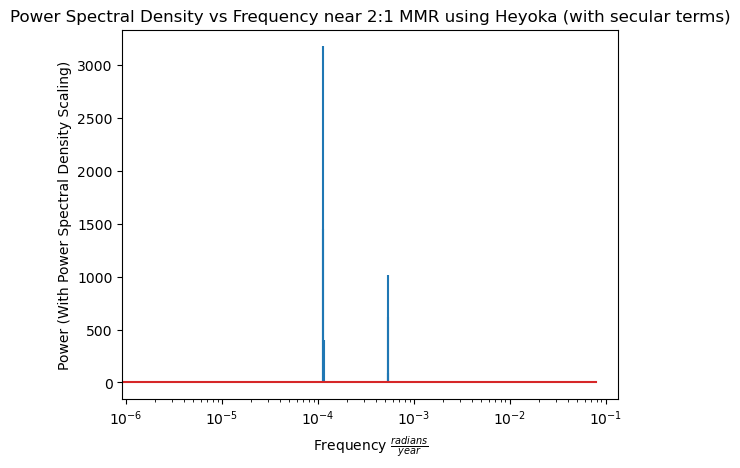

In [45]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.85,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(max_order=2, indexIn = 1, indexOut=2)
pham.add_cosine_term([2,-1,-1,0,0,0],indexIn=1,indexOut=2)
#pham.add_cosine_term([2,-1,0,-1,0,0],indexIn=1,indexOut=2)

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
a_sat = np.zeros(len(times))

e_i = pham.calculate_energy()
print('Initial Energy: '+ str(e_i))

times, pomega_sat, e_sat, a_sat = hk_integrate(pham, 4e6, 1e5)

f_hy,pxx_hy = pomega_ft(times, pomega_sat, e_sat)

plt.stem(f_hy*2*np.pi,pxx_hy,markerfmt = "none",label = 'Frequencies found through simulation')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency near 2:1 MMR using Heyoka (with secular terms)')